In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import numpy as np
from matplotlib import pyplot as plt

import datasets_util
import vis_util
import lpca
from lego import lego, util

VIS = vis_util.Visualize('figures/swissroll/')

matplotlib.get_backend() =  inline


In [3]:
nturns = 6
RES = 100
theta0 = 3*np.pi/2
rmax = 1e-2
X0, labels0 = datasets_util.noisyswissroll(RES=RES, noise=0, nturns=nturns, theta0=theta0, rmax=rmax)
X, labels = datasets_util.noisyswissroll(RES=RES, noise=0.0175, noise_type='ortho-uniform', nturns=nturns, theta0=theta0, rmax=rmax)

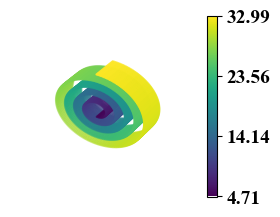

In [4]:
VIS.data(X0, labels0[:,0], cmap='viridis', s=2, figsize=(3,3), colorbar=True, show_axis=False, save_fn='clean_data')

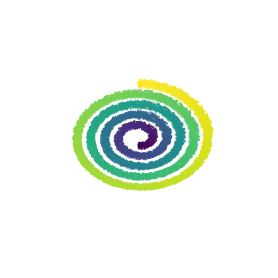

In [5]:
VIS.data(X, labels0[:,0], cmap='viridis', s=2, azim=-92, elev=-3, figsize=(3,3), show_axis=False, save_fn='noisy_data_side_view')

In [6]:
# a subsample of points to visualize tangent spaces
n_subsample = 300
np.random.seed(42)
subsample_inds = np.random.choice(np.arange(X.shape[0]), n_subsample, replace=False)

In [7]:
emb_dim = 2
k_nn = 9

# LPCA on noiseless data

In [8]:
gt_estimate = lpca.lpca(X0, opts = {'emb_dim': emb_dim, 'k_nn': k_nn})

In [9]:
gt_estimate['tang_basis'].shape

(10700, 2, 3)

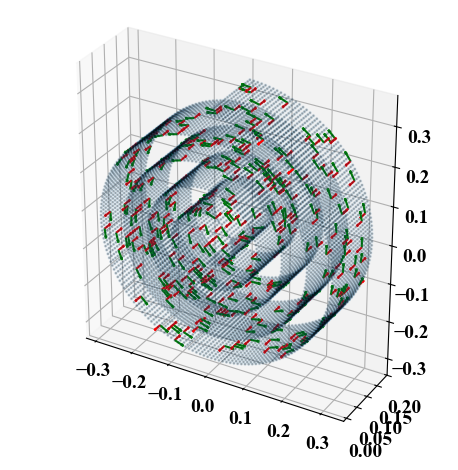

In [10]:
VIS.plot_tangent_vectors_2d_in_3d(
    gt_estimate['tang_basis'],
    X0, X0, subsample_inds,
    title='', save_fn='gt_tang_basis'
)

# LPCA on noisy data

In [11]:
lpca_estimate = lpca.lpca(X, opts = {'emb_dim': emb_dim, 'k_nn': k_nn})

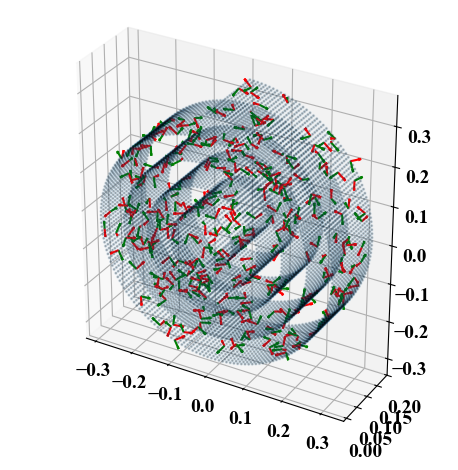

In [12]:
VIS.plot_tangent_vectors_2d_in_3d(
    lpca_estimate['tang_basis'],
    X0, X0, subsample_inds,
    title='', save_fn='lpca_tang_basis'
)

# LEGO on noisy data

In [13]:
n_eig_for_grad = 40
n_eig = 100
lego_estimate = lego.lego(
    X,
    opts={'emb_dim': emb_dim, 'k_nn': k_nn, 'n_eig_for_grad': n_eig_for_grad}, 
    gl_opts={'n_eig': n_eig}
)

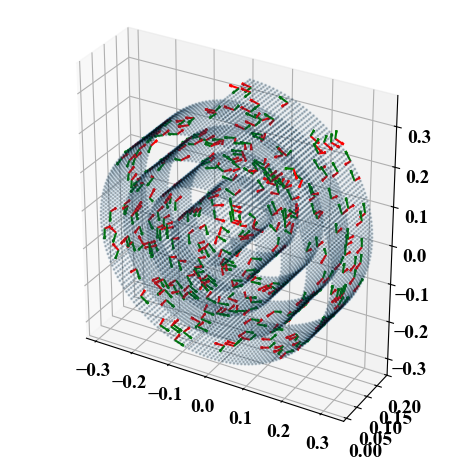

In [14]:
VIS.plot_tangent_vectors_2d_in_3d(
    lego_estimate['tang_basis'],
    X0, X0, subsample_inds,
    title='', save_fn='lego_tang_basis'
)

# Error of LPCA and LEGO estimates

In [15]:
color = {'lpca': 'red', 'lego': 'green'}
error = {
    'lpca': {'lpca': util.tang_basis_estimate_error(lpca_estimate['tang_basis'], gt_estimate['tang_basis'])},
    'lego': {'lego': util.tang_basis_estimate_error(lego_estimate['tang_basis'], gt_estimate['tang_basis'])},
}

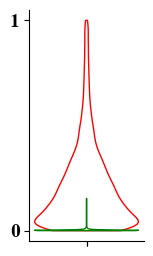

In [16]:
_ = VIS.global_distortion_viloinplot_overlay(
    error, log_scale=False, legend=False, filled=False,
    color = color, remove_annotation=True, offset2=0, offset1=0,
    title='', label='', figsize=(2,3), save_fn='error_violins'
)

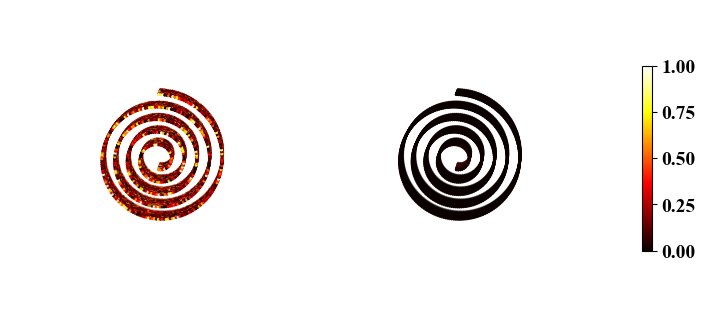

In [17]:
VIS.compare_principal_angle_discrep(
    X0, [error['lpca']['lpca'], error['lego']['lego']],
    vmin=0, vmax=1, cmap='hot', azim=-87, elev=10, save_fn='lpca_vs_lego_tang_estimate_errors'
)

# Local intrinsic dimension estimation

We simply change the embedding dimension to be equal to the ambient dimension plot the variance explained in each dimension

In [18]:
ambient_dim = X.shape[1]

In [19]:
lpca_estimate_for_lid = lpca.lpca(X, opts = {'emb_dim': ambient_dim, 'k_nn': k_nn})

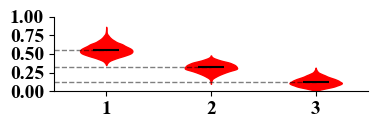

In [20]:
VIS.plot_var_exp_violin_plot(
    lpca_estimate_for_lid['var_explained'], color='r', save_fn='lpca_lid_estimate'
)

In [21]:
lego_estimate_for_lid = lego.lego(
    X,
    opts={'emb_dim': ambient_dim, 'k_nn': k_nn, 'n_eig_for_grad': n_eig_for_grad}, 
    gl_opts={'n_eig': n_eig}
)

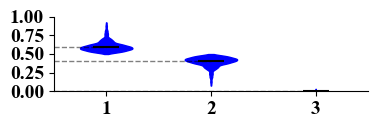

In [22]:
VIS.plot_var_exp_violin_plot(
    lego_estimate_for_lid['var_explained'], color='b', save_fn='lego_lid_estimate'
)

# Boundary detection

Note that opts['k_nn'] and opts['k_tune'] set here are specific to boundary detection and has nothing to do with tangent space estimation.

For more details please refer to https://arxiv.org/abs/2411.18942

The source `bx_util.py` is derived from https://github.com/chiggum/robust_boundary_estimation/tree/19f90ff6676e4fe99c417b324431a5e04f15890e

In [23]:
import sys
import paths_private_
sys.path.insert(0, paths_private_.codebase_path + '/robust_boundary_estimation/src/')
import bx_util

In [24]:
opts = bx_util.default_opts.copy()
opts['k_nn'] = 128
opts['k_tune'] = 32
opts['local_subspace'] = gt_estimate['tang_basis'].transpose(0, 2, 1) # emb_dim is the last dimension
opts['d'] = 2
gt_bx = bx_util.estimate_bx(X, opts=opts)[0]

0.0022422680270582944
0.00028051369490801045
0.00010216831192884167
5.838940031965367e-05
4.135601947775173e-05
3.1799188716067036e-05
2.5179184214211255e-05
2.0186030285241325e-05
1.6924258592061744e-05
1.3021319138033328e-05
1.00338604796642e-05
7.920077747934102e-06
5.900154708111252e-06
4.5477282445830035e-06
3.6635224922094374e-06
3.0680906931619878e-06
2.7302194066177585e-06
2.566631387454491e-06
2.28209414579945e-06
2.170795319029039e-06
1.992687058952481e-06
1.808791368543317e-06
1.465886400648816e-06
1.2938624857358327e-06
1.151546661809054e-06
9.108056084999372e-07
h_per_point min max median 0.03481522373306248 0.03516088098579777 0.03491042468294044
Sinkhorn converged at iter: 16


In [25]:
opts = bx_util.default_opts.copy()
opts['k_nn'] = 128
opts['k_tune'] = 32
opts['local_subspace'] = lpca_estimate['tang_basis'].transpose(0, 2, 1) # emb_dim is the last dimension
opts['d'] = 2
lpca_bx = bx_util.estimate_bx(X, opts=opts)[0]

0.0022422680270582944
0.00028051369490801045
0.00010216831192884167
5.838940031965367e-05
4.135601947775173e-05
3.1799188716067036e-05
2.5179184214211255e-05
2.0186030285241325e-05
1.6924258592061744e-05
1.3021319138033328e-05
1.00338604796642e-05
7.920077747934102e-06
5.900154708111252e-06
4.5477282445830035e-06
3.6635224922094374e-06
3.0680906931619878e-06
2.7302194066177585e-06
2.566631387454491e-06
2.28209414579945e-06
2.170795319029039e-06
1.992687058952481e-06
1.808791368543317e-06
1.465886400648816e-06
1.2938624857358327e-06
1.151546661809054e-06
9.108056084999372e-07
h_per_point min max median 0.03481522373306248 0.03516088098579777 0.03491042468294044
Sinkhorn converged at iter: 16


In [26]:
opts = bx_util.default_opts.copy()
opts['k_nn'] = 128
opts['k_tune'] = 32
opts['local_subspace'] = lego_estimate['tang_basis'].transpose(0, 2, 1) # emb_dim is the last dimension
opts['d'] = 2
lego_bx = bx_util.estimate_bx(X, opts=opts)[0]

0.0022422680270582944
0.00028051369490801045
0.00010216831192884167
5.838940031965367e-05
4.135601947775173e-05
3.1799188716067036e-05
2.5179184214211255e-05
2.0186030285241325e-05
1.6924258592061744e-05
1.3021319138033328e-05
1.00338604796642e-05
7.920077747934102e-06
5.900154708111252e-06
4.5477282445830035e-06
3.6635224922094374e-06
3.0680906931619878e-06
2.7302194066177585e-06
2.566631387454491e-06
2.28209414579945e-06
2.170795319029039e-06
1.992687058952481e-06
1.808791368543317e-06
1.465886400648816e-06
1.2938624857358327e-06
1.151546661809054e-06
9.108056084999372e-07
h_per_point min max median 0.03481522373306248 0.03516088098579777 0.03491042468294044
Sinkhorn converged at iter: 16


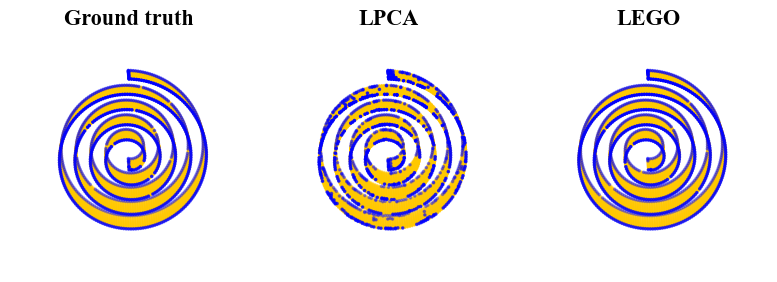

In [29]:
vis_util.plot_detected_boundary(
    X0,
    [gt_bx, lpca_bx, lego_bx],
    ['Ground truth', 'LPCA', 'LEGO'],
    max_prctile = 10, elev=14, azim=-91,
    save_fpath=VIS.save_dir+'/boundaries.png',
    figsize=(8,3)
)

# Manifold Learning

The source is derived from feature/global-opts branch of https://github.com/Mishne-Lab/pyRATS commit: 8ad44b32a82cd6e52ad6ec17bd8b5917ec037582

Several options are turned off as these may improve the distortion of the low-dimensional local views obtained via projection on the estimated tangent spaces.

- `to_postprocess = False` prevents any postprocessing on local views computed from the tangent space estimates.
- `eta_min = 1` prevents formation of intermediate views (as they may improve upon local views).

Note that `eta_min = 1` significantly increases the time complexity of the algorithm, however, our main goal here is to evaluate the effect of tangent space estimates on the derived embedding without interference from the remaining components of the algorithm.

We also turned off `to_tear = False` to prevent intentional tearing of the manifold.

For more details please refer to https://www.biorxiv.org/content/10.1101/2024.10.31.621292v2

In [30]:
import sys
sys.path.insert(0, paths_private_.codebase_path + '/pyRATS/src/')
from pyRATS import rats

def generate_embedding(point_cloud, model, tang_basis):
    model._fit_nbrhd_graph(point_cloud)
    model._fit_local_views(point_cloud)

    # override the local views using the estimated tangent basis
    model.param.Psi = tang_basis.transpose(0, 2, 1) # emb_dim is the last dimension
    
    c, n_C = model._fit_intermediate_views()
    y = model._fit_global_views(c, n_C)
    return y

In [29]:
model = rats.RATS(d=emb_dim, k=k_nn, alpha=1, max_iter=5, to_postprocess=False, eta_min=1, to_tear=False)
y_gt = generate_embedding(X, model, gt_estimate['tang_basis'])

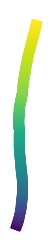

In [30]:
VIS.data(
    y_gt, labels[:,0], cmap='viridis', figsize=(3,3), save_fn='y_gt', show_axis=False, s=1,
)

In [31]:
model = rats.RATS(d=emb_dim, k=k_nn, alpha=1, max_iter=5, to_postprocess=False, eta_min=1, to_tear=False)
y_lpca = generate_embedding(X, model, lpca_estimate['tang_basis'])

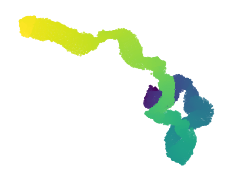

In [32]:
VIS.data(
    y_lpca, labels[:,0], cmap='viridis', figsize=(3,3), save_fn='y_lpca', show_axis=False, s=1
)

In [31]:
model = rats.RATS(d=emb_dim, k=k_nn, alpha=1, max_iter=5, to_postprocess=False, eta_min=1, to_tear=False)
y_lego = generate_embedding(X, model, lego_estimate['tang_basis'])

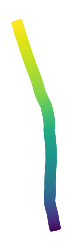

In [32]:
VIS.data(
    y_lego, labels[:,0], cmap='viridis', figsize=(3,3), save_fn='y_lpca', show_axis=False, s=1
)

# Noise ablation

In [33]:
max_noise_level = 0.0175
noise_levels = np.linspace(0, 1, 5)

In [34]:
error_per_noise_level = {}
for i in range(len(noise_levels)):
    X_i, labels_i = datasets_util.noisyswissroll(
        RES=RES, noise=max_noise_level*noise_levels[i], noise_type='ortho-uniform', nturns=nturns, theta0=theta0, rmax=rmax
    )
    lpca_estimate_i = lpca.lpca(X_i, opts = {'emb_dim': emb_dim, 'k_nn': k_nn})
    lego_estimate_i = lego.lego(
        X_i,
        opts={'emb_dim': emb_dim, 'k_nn': k_nn, 'n_eig_for_grad': n_eig_for_grad}, 
        gl_opts={'n_eig': n_eig}
    )
    error_per_noise_level[i] = {
        'LPCA': util.tang_basis_estimate_error(lpca_estimate_i['tang_basis'], gt_estimate['tang_basis']),
        'LEGO': util.tang_basis_estimate_error(lego_estimate_i['tang_basis'], gt_estimate['tang_basis']),
    }

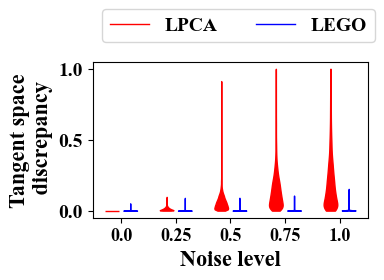

In [35]:
color = {'LPCA': 'red', 'LEGO': 'blue'}
xticks = VIS.global_distortion_viloinplot_overlay(
    error_per_noise_level, log_scale=False,
    legend=True, filled=True, bbox_to_anchor_=(0, 1.1, 0.3, 0.3), ncol=2,
    prop={'size':14}, loc_='upper left', widths=0.75,
    color = color, remove_annotation=False, offset2=1, offset1=1,
    title='', label='', figsize=(4,3), save_fn='noise_ablation'
)
plt.xticks([0.5, 3.5, 6.5, 9.5, 12.5], [np.round(nl, 4) for nl in noise_levels], fontsize=13)
plt.xlabel('Noise level')
plt.ylabel('Tangent space\n discrepancy')
plt.tight_layout()
plt.savefig(VIS.save_dir + 'noise_ablation_annotated.png', dpi=600)
plt.show()

# Hyperparameter ablation: varying number of eigenvectors

In [36]:
n_eig_for_grad_list = np.arange(10, 131, 10).astype('int32')
n_eig_list = (n_eig_for_grad_list > 50) * 100 + 100
X_max_noise_level, _ = datasets_util.noisyswissroll(
    RES=RES, noise=max_noise_level, noise_type='ortho-uniform', nturns=nturns, theta0=theta0, rmax=rmax
)

In [37]:
error_per_n_eig = {}
for i in range(len(n_eig_list)):
    n_eig_i = int(n_eig_list[i])
    n_eig_for_grad_i = int(n_eig_for_grad_list[i])
    
    lego_estimate_i = lego.lego(
        X_max_noise_level,
        opts={'emb_dim': emb_dim, 'k_nn': k_nn, 'n_eig_for_grad': n_eig_for_grad_i}, 
        gl_opts={'n_eig': n_eig_i}
    )
    
    error_per_n_eig[i] = {
        'LEGO': util.tang_basis_estimate_error(lego_estimate_i['tang_basis'], gt_estimate['tang_basis']),
    }

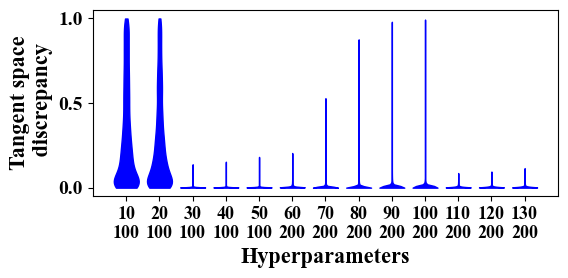

In [38]:
color = {'LEGO': 'blue'}
xticks = VIS.global_distortion_viloinplot_overlay(
    error_per_n_eig, log_scale=False,
    legend=False, filled=True, widths=0.75,
    color = color, remove_annotation=False, offset2=0, offset1=1,
    title='', label='', figsize=(6,3), save_fn='hyperparam_ablation'
)
xticks_labels = []
for i in range(len(n_eig_list)):
    xticks_labels.append(str(n_eig_for_grad_list[i])+'\n'+str(n_eig_list[i]))
plt.xticks(np.arange(len(n_eig_for_grad_list)), xticks_labels, fontsize=13)
plt.ylabel('Tangent space\n discrepancy')
plt.xlabel('Hyperparameters')
plt.tight_layout()
plt.savefig(VIS.save_dir + 'hyperparam_ablation_annotated.png', dpi=600)
plt.show()

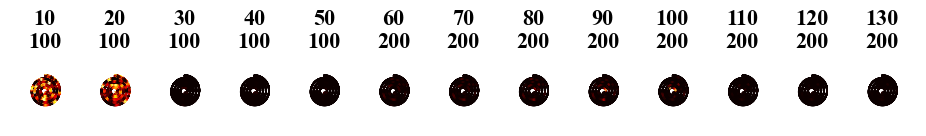

In [39]:
fig = plt.figure(figsize=(len(n_eig_list)*0.9, 2))
axes = []
for i in range(len(n_eig_list)):
    axes.append(fig.add_subplot(1, len(n_eig_list), i+1, projection='3d'))
    axes[i].view_init(azim=-87, elev=10)

for i in range(len(n_eig_list)):
    plt.subplots_adjust(wspace=0, hspace=0)
    p = axes[i].scatter(*X0.T, c=error_per_n_eig[i]['LEGO'], cmap='hot', vmin=0, vmax=1, s=0.25)
    axes[i].set_title(str(n_eig_for_grad_list[i])+'\n'+str(n_eig_list[i]))
    axes[i].axis('off')
    axes[i].axis('equal')
    
#fig.colorbar(p, ax=axes, orientation='vertical', shrink=0.5)
plt.savefig(VIS.save_dir + '/hyperparam_ablation_error_plotted_on_X.png', dpi=600)

# ISOMAP embeddings

n_neighbors: 5


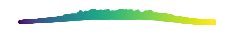

n_neighbors: 8


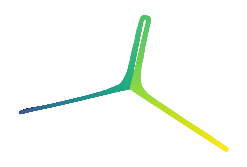

n_neighbors: 9


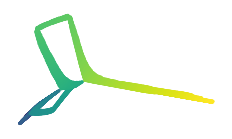

n_neighbors: 10


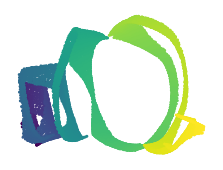

n_neighbors: 25


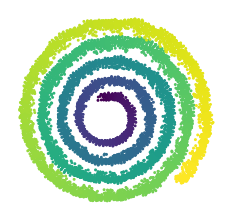

In [40]:
from sklearn.manifold import Isomap
isomap_n_neighbors = [5, 8, 9, 10, 25]
for n_neighbors in isomap_n_neighbors:
    print('n_neighbors:', n_neighbors, flush=True)
    isomap_obj = Isomap(n_neighbors=n_neighbors, n_components=emb_dim, n_jobs=-1)
    y = isomap_obj.fit_transform(X)
    VIS.data(y, labels[:,0], cmap='viridis', figsize=(3,3), show_axis=False)
    plt.show()